In [14]:
# Importing Necessary Libraries
import polars as pl
import matplotlib.pyplot as plt

In [15]:
df = pl.read_csv("data/survey_results_public.csv")

print(df.shape)

(65437, 114)


#LOAD Dataset

In [16]:
def load_data():
    df = pl.read_csv("data/survey_results_public.csv")
    return df

#CLEAN DATA

In [17]:
def clean_data(df):

    df = df.with_columns(
        pl.col("ConvertedCompYearly")
        .str.replace_all(r"[^0-9.]", "")
        .cast(pl.Float64, strict=False)
        .alias("ConvertedCompYearly")
    )

    df = df.filter(
        pl.col("ConvertedCompYearly").is_not_null()
    )

    return df

In [18]:
def salary_by_country(df):

    return (
        df.group_by("Country")
        .agg(
            pl.col("ConvertedCompYearly")
            .mean()
            .alias("AverageSalary")
        )
        .sort("AverageSalary", descending=True)
    )

def salary_by_experience(df):

    return (
        df.group_by("YearsCodePro")
        .agg(
            pl.col("ConvertedCompYearly")
            .mean()
            .alias("AverageSalary")
        )
    )

def salary_by_remote(df):

    return (
        df.group_by("RemoteWork")
        .agg(
            pl.col("ConvertedCompYearly")
            .mean()
            .alias("AverageSalary")
        )
    )

In [19]:
def country_salary_chart(result):

    top10 = result.head(10)
    countries = top10["Country"].to_list()
    salaries = top10["AverageSalary"].to_list()

    plt.figure(figsize=(10,5))

    plt.bar(countries, salaries)

    plt.xticks(rotation=45)

    plt.title("Top 10 Countries by Average Salary")

    plt.tight_layout()

    plt.show()

shape: (10, 2)
┌──────────────────────────┬───────────────┐
│ Country                  ┆ AverageSalary │
│ ---                      ┆ ---           │
│ str                      ┆ f64           │
╞══════════════════════════╪═══════════════╡
│ Gabon                    ┆ 2e6           │
│ Ethiopia                 ┆ 934570.157895 │
│ United States of America ┆ 161072.335685 │
│ Singapore                ┆ 136150.472727 │
│ South Africa             ┆ 132393.854545 │
│ Taiwan                   ┆ 127319.969388 │
│ Antigua and Barbuda      ┆ 126120.0      │
│ Andorra                  ┆ 123517.0      │
│ Israel                   ┆ 119981.972851 │
│ Switzerland              ┆ 118554.660622 │
└──────────────────────────┴───────────────┘


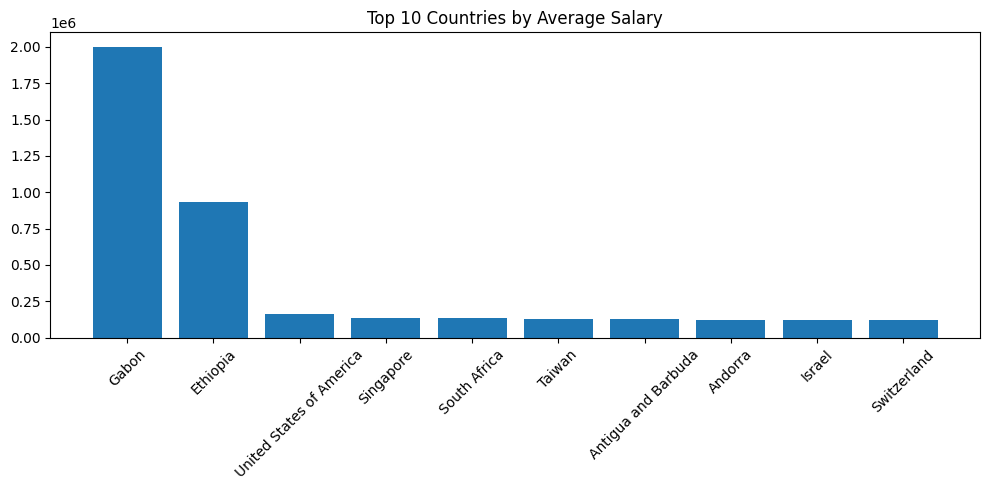

In [20]:
# from load_data import load_data
# from clean_data import clean_data
# from src.analysis import *
# from src.visualization import *

df = load_data()

df = clean_data(df)

country_result = salary_by_country(df)

print(country_result.head(10))

country_salary_chart(country_result)    

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Train a salary prediction model using key features from the dataset
cleaned_df = df.with_columns(
    pl.col("YearsCodePro").str.replace_all(r"[^0-9.]", "").cast(pl.Float64, strict=False)
).filter(
    pl.col("YearsCodePro").is_not_null() &
    pl.col("RemoteWork").is_not_null()
)

model_df = cleaned_df.select([
    "Country",
    "YearsCodePro",
    "RemoteWork",
    "ConvertedCompYearly"
]).to_pandas()

feature_columns = ["Country", "YearsCodePro", "RemoteWork"]

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["Country", "RemoteWork"],
        )
    ],
    remainder="passthrough",
)

salary_model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", Ridge()),
    ]
)

salary_model.fit(model_df[feature_columns], model_df["ConvertedCompYearly"])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Country','YearsCodePro','RemoteWork']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transfo

In [24]:
# Manual input for prediction
manual_input = {
    "Country": ["Canada"],
    "YearsCodePro": [5.0],
    "RemoteWork": ["Fully remote"],
}
manual_df = pl.DataFrame(manual_input).to_pandas()

predicted_salary = salary_model.predict(manual_df)[0]
print(f"Manual input: {manual_input}")
print(f"Predicted yearly salary: ${predicted_salary:,.2f}")

Manual input: {'Country': ['Canada'], 'YearsCodePro': [5.0], 'RemoteWork': ['Fully remote']}
Predicted yearly salary: $75,754.76
